<div style="width: 100%; overflow: hidden;">
    <a href="http://www.uc.pt/fctuc/dei/">
    <div style="display: block;margin-left: auto;margin-right: auto; width: 100%;"><img src="https://eden.dei.uc.pt/~naml/images_ecos/dei25.png"  /></div>
    </a>
</div>

In [1905]:
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# Just to make plots look better
plt.rcParams["figure.figsize"] = (20,12)
plt.rcParams['axes.grid'] = True
plt.style.use('fivethirtyeight')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['lines.linewidth'] = 3

<h2><font color='#3498db'>Optimization and Machine Learning </font></h2>

In this notebook we will describe fundamental optimisation algorithms that use the *first derivative* or *gradient* of a function. These techniques are fundamental in data science, because we optimise a lot of things. For instance, in linear regression, our goal is to optimize the model's intercept and coefficients. In clustering techniques such as k-means, we want to enhance our cluster configurations. In neural networks, our focus is to optimise the network's weights (mote on this later), among other examples.

Consider that you have a function $f(x)$. Simply put, *optimization* corresponds to finding the values of $x$ that correspond to the maximum/minimum of $f(x)$. For example, if $f(x)=(x-2)^2+10$ what is the value of $x$ for which $f(x)$ is minimal? You can solve it analitycaly, and discover that the answer is $x=2$ and $f(x)=10$.

We can think of Machine Learning as having three steps:

1. Select a model: controls the space of possible functions that map a set of points $X$ to $y$. For example, a linear model can only learn linear mappings, i.e., functions, between $X$ and $y$ 
2. Choose a loss function: it  allows us to compare different models, e.g., is $y=5 + 0.5x$ a better model than $y=2 + 6x$?
3. Choose an optisation algorithm: finds the parameters of the model that give the lowest value for the loss function. In other words, it finds optimum value for $w0$ and $w_1$ in $y=w_0+w_1x$

In this class we will be looking at the optimization procedures and how they are used in machine. In particular we will be looking into a widely used method know as gradient descent.


<h2><font color='#3498db'>Loss Functions </font></h2>
Loss functions, also frequently referred to as "objective functions" or "cost functions" (though there's some discussion about subtle differences between these terms), serve as the means to quantify a model's performance by mapping it to a real number, and they represent the target of our optimization efforts. Take, for instance, the mean squared error (MSE), a widely used loss function:

$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i )^2$

where
- $n$ is the number of observations
- $y_i$ is the actual value of the i-th observation
- $\hat{y}_i$ is the predicted value (the output of our model) for the i-th observation

If we consider a simple linear regression model $\hat{y_i}=w_0+w_1x_i$, our loss function, i.e., the $MSE$ is:

$f(y, x, w) = \frac{1}{n} \sum_{i=1}^{n} ((w_0+w_1x_i) - y_i )^2$

***Thus the optimization problem is to find the values of $w_0$ and $w_1$ that minimize $f(y, x, w)$***!

<h2><font color='#3498db'>Problem Statement</font></h2>
In order to understand how optimization works, we will use linear regression to build a model to predict the attack of a Pokemon based on its defense. For sake of simplicity we will consider 10 pokemons:

In [1906]:
df = pd.read_csv("pokemon.csv", usecols=['name', 'defense', 'attack'], index_col=0, nrows=10).reset_index()
df

,name,attack,defense
0,Bulbasaur,49,49
1,Ivysaur,62,63
2,Venusaur,100,123
3,Charmander,52,43
4,Charmeleon,64,58
5,Charizard,104,78
6,Squirtle,48,65
7,Wartortle,63,80
8,Blastoise,103,120
9,Caterpie,30,35


In [1907]:
# Rename our variables to match the the model y = w0 + w1 * x, and covert it to PyTorch
x = torch.from_numpy(df['defense'].values).float()
y = torch.from_numpy(df['attack'].values)

print(x)
print(y)

tensor([ 49.,  63., 123.,  43.,  58.,  78.,  65.,  80., 120.,  35.])
tensor([ 49,  62, 100,  52,  64, 104,  48,  63, 103,  30])


[Text(0.5, 0, 'defense'), Text(0, 0.5, 'attack')]

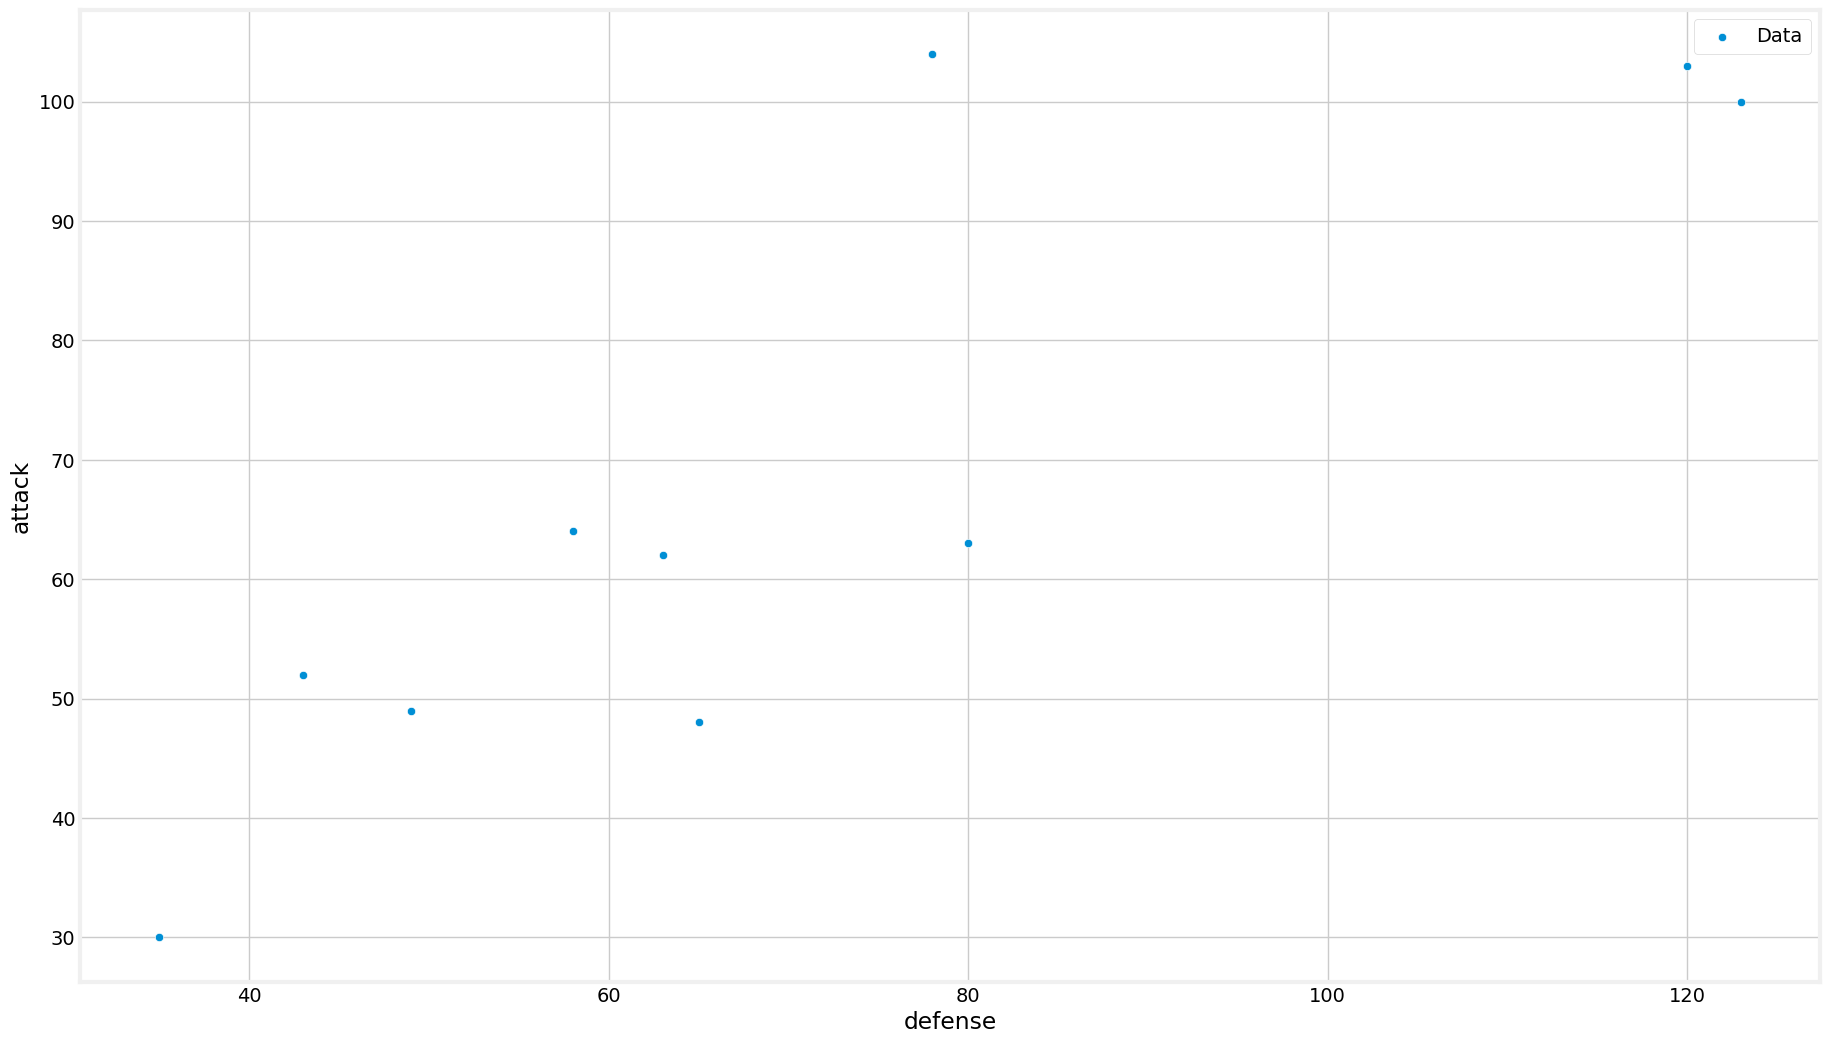

In [1908]:
ax = sns.scatterplot(x=x,y=y, label="Data")
ax.set(xlabel='defense', ylabel='attack')

In linear regression: $\hat{y}_i=w_0 + w_1x_i$ (where $w_0$ is the intercept and $w_1$ is the slope coefficient). If we assume $(w_0, w_1) = (8, 0.3)$ then we would have:

<Axes: xlabel='defense', ylabel='attack'>

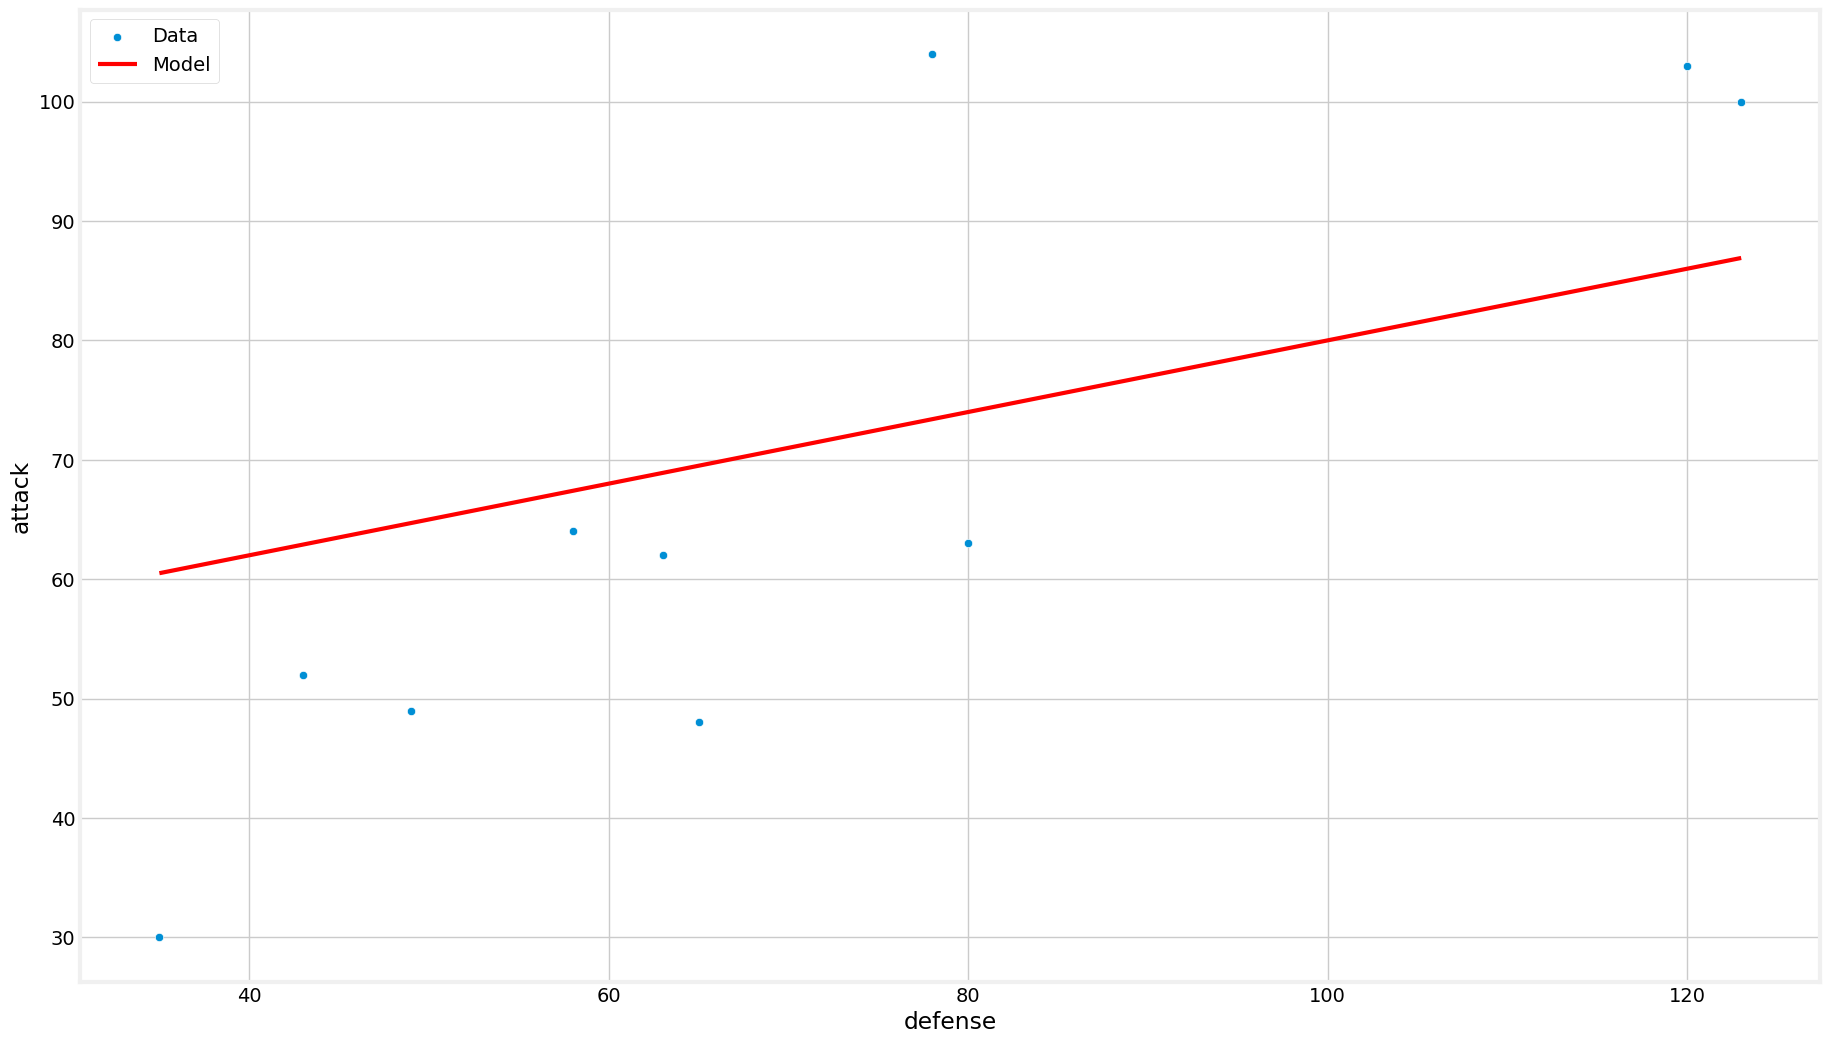

In [1909]:
y_hat = 50 + 0.3 * x
ax = sns.scatterplot(x=x,y=y, label="Data")
ax.set(xlabel='defense', ylabel='attack')
sns.lineplot(x=x, y=y_hat, ax=ax, label='Model', color='red')

The line does not fit the data very well... we need to look for the $w_0$, $w_1$ that give us a better fit. In other words: ***We need to optimize it!***

A loss function can help quantify the fit of our model and we want to find the parameters of our model that minimize the loss function. We’ll use mean-squared-error (MSE) as our loss function (see above).

In [1910]:
# MSE loss
def mse(t1, t2):
    diff = t1 - t2
    return torch.sum(diff * diff) / diff.numel()
mse(y, y_hat)

tensor(333.4940)

The value above is the MSE across all training examples, for the example we considered. We can see confirm that the fit is not very good, given the MSE value.
Lets now focus on finding a suitable a $w_1$ and a $w_0$ using the training data, to make accurate predictions.

<h2><font color='#3498db'>Gradient Descent with One Parameter</font></h2>
Gradient descent is an optimization technique designed to minimize our loss function in an efficient manner. The method relies on the gradient of the loss function, which is essentially a vector comprised of the (partial) derivatives of the loss function with respect to the model parameters. While this might sound complex, it's quite straightforward in practice, as we'll see.
Simply put the gradient gives us information about two things:

1. The direction to adjust our parameter that will decrease the loss ( (i.e., should we increase or decrease its value?))
2. How much should it be adjusted (for example, should the adjustment be 0.1, 2, or 50, etc.)?

For now, lets consider that $w_0 = 0$, which results in the following model: $\hat{y}_i= w_1x_i$, which results in the following loss function:

$f(x, y, w_1) = \frac{1}{n} \sum_{i=1}^{n} ((w_1x_i) - y_i )^2$

The derivative, i.e., gradient, of $f$ with respect to $w_1$ is:

$\frac{d}{dw_1}f(x, y, w_1) = \frac{1}{n} \sum_{i=1}^{n} 2x_i((w_1x_i) - y_i)$

In [1911]:
def gradient(x, y, w):
    return  torch.mean(2 * (x * ((w * x) - y)))

gradient(x, y, 0.3)

tensor(-7304.6406)

This represents the gradient across all training examples, indicating the adjustments needed for  $w_1$ to minimize the MSE loss across the entire training set. Remembering our calculus, the gradient points towards the direction of steepest increase. However, to lower our loss, we aim to move in the direction of steepest decrease, which is the opposite direction of the gradient. For instance, although the gradient mentioned earlier is negative, to diminish our loss, it's clear that we need to raise the value of our slope $w_1$ (see the plot above).

The degree to which we modify our slope in each iteration is governed by a parameter known as the *learning rate*, symbolized by $\alpha$. It's important to note the presence of a minus sign in the equation below, which is responsible for reversing the direction of the gradient, aligning with our earlier discussion:

$w_{new} = w - \alpha * gradient$

$w_{new} = w - \alpha * \frac{d}{dw_1}f(x, y, w)$

where $\alpha$ is a hyperparameter with typical values spanning from 0.001 to 0.9. Having addressed the mathematical foundations, we are now ready to use gradient descent for the optimization of our slope. As an iterative technique, gradient descent involves repeated application until reaching a predetermined stopping condition. Commonly, we stop the gradient descent process when:

1. the step size is smaller than some pre-defined threshold; or,
2. a certain number of steps is completed.

The pseudocode for the gradient descent is the following:


***input:*** function $f$, initial point $w$, maximum number of steps($K$), threshold $\epsilon$,  a learning rate $\alpha$

`while` stop criteria not met

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $w_{new} = w - \alpha * \frac{d}{dw_1}f(x, y, w)$

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $w = w_{new}$

***output:*** $w$


In [1912]:
def gradient_descent(x, y, w, alpha, max_steps=5000, epsilon=1e-4, report_progress=10):
    print(f'Iteration 0. w = {w}.')
    step = 0
    dw = 2 * epsilon 
    while abs(dw) > epsilon and step < max_steps:
        g = gradient(x, y, w)
        dw = alpha * g
        w = w - dw
        if step % report_progress == 0:
            print(f'Iteration {step}. w = {w}.')
        step += 1
    print(f'Iteration {step - 1}. w = {w}.')
    return w
w_new = gradient_descent(x, y, torch.tensor([1.2]), 0.2)

Iteration 0. w = tensor([1.2000]).
Iteration 0. w = tensor([-663.5281]).
Iteration 10. w = tensor([-3.5738e+36]).
Iteration 13. w = tensor([nan]).


Let's now visualise the fitted model.

tensor(nan)

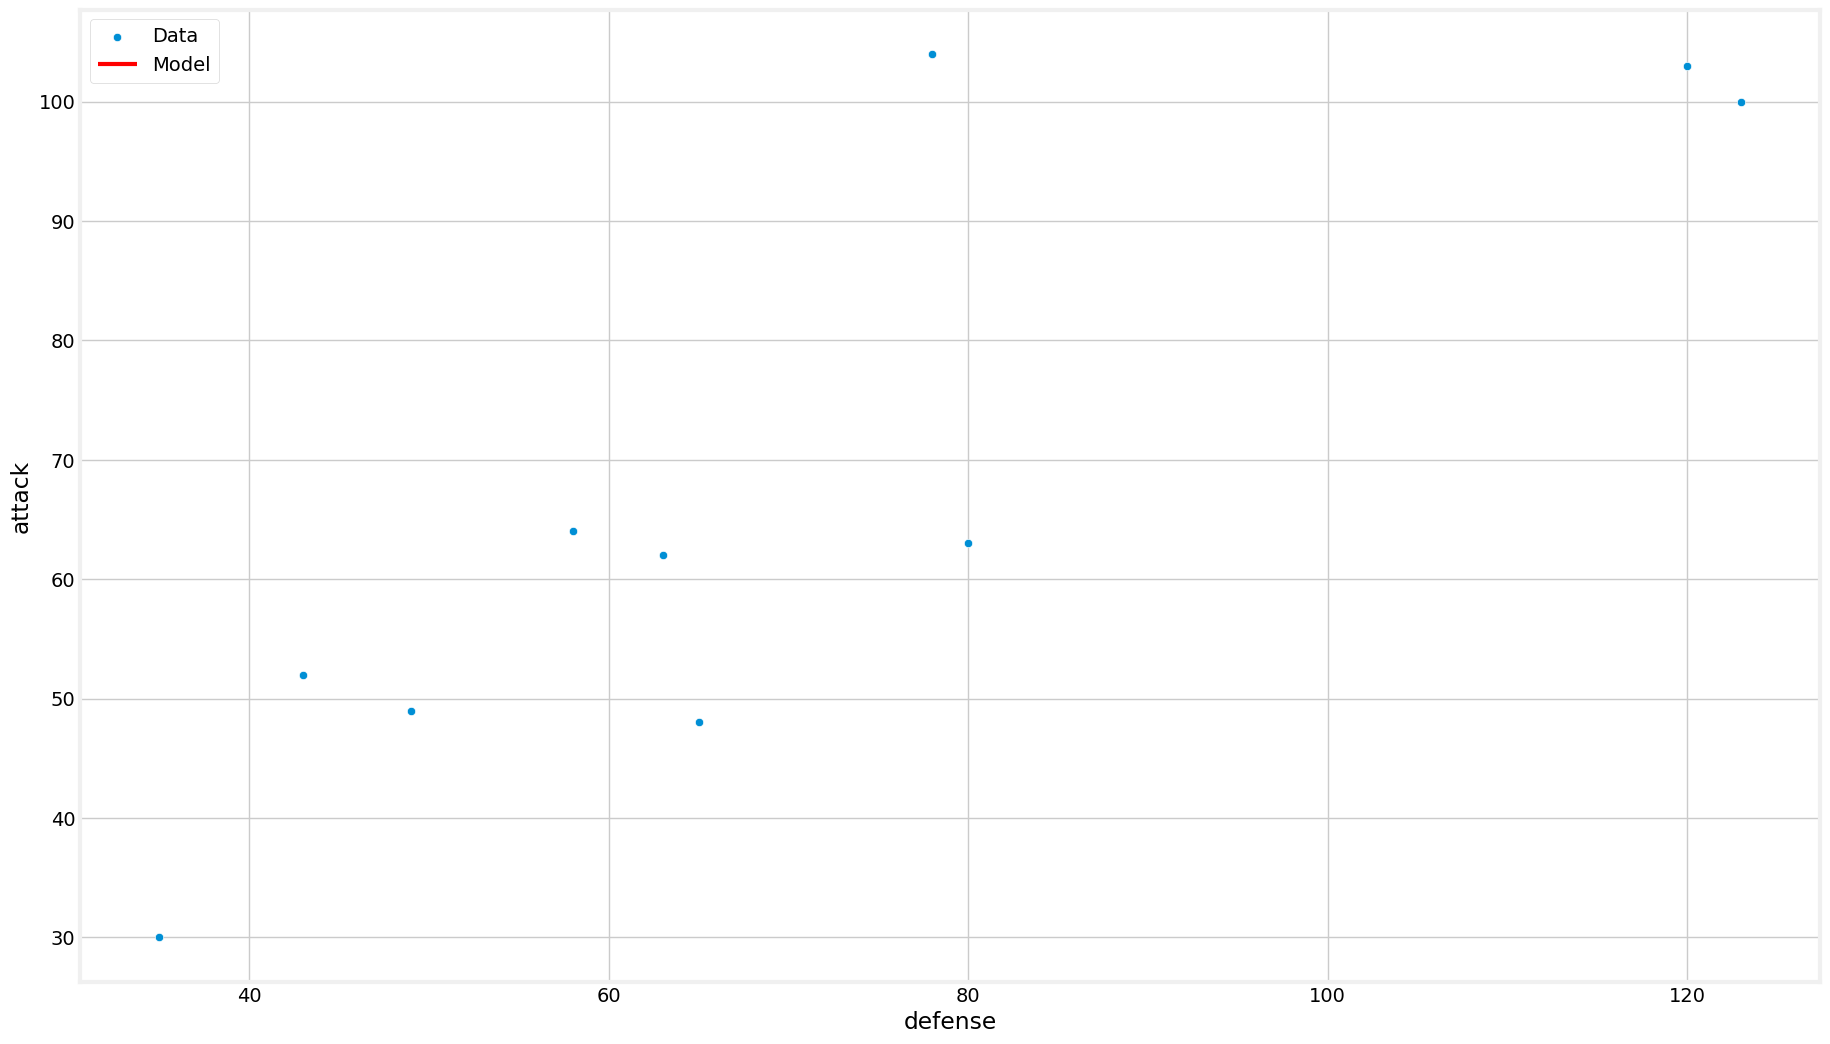

In [1913]:
y_hat = w_new * x
ax = sns.scatterplot(x=x,y=y, label="Data")
ax.set(xlabel='defense', ylabel='attack')
sns.lineplot(x=x, y=y_hat, ax=ax, label='Model', color='red')
mse(y, y_hat)

#### <span style="color:green">Exercise 1</span>  
<span style="color:green">Using the code above, analyse the impact of different learning rates. What happens if the learning rate is too high? And too low?</span>

- ***Answer:***
    - In gradient descent, the learning rate plays a critical role in determining how quickly the algorithm converges to the optimal solution. If the learning rate is too high or too low, it can significantly impact the performance of the algorithm and the final model.

    1. **Impact of a Too High Learning Rate:**
        - Overshooting the Minimum: If the learning rate is too high, the updates to the weights can be too large, causing the algorithm to overshoot the minimum (i.e., the optimal value of w). Instead of converging towards the minimum, it may jump around, resulting in no convergence at all.
        - Divergence: In extreme cases, a very high learning rate can cause the algorithm to diverge, meaning the model parameters will continuously increase or decrease without stabilizing.
        - Noisy Behavior: The algorithm will exhibit erratic or noisy behavior, which can be seen in a lack of smooth progress in the output of each iteration.
        - Symptoms in your code: If the learning rate is too high, you might observe that the model fails to fit the data well, even after many iterations. The value of w might fluctuate wildly, and the final MSE (mean squared error) could be large or unstable.

    2. **Impact of a Too Low Learning Rate:**
        - Slow Convergence: If the learning rate is too low, the weight updates will be very small, causing the algorithm to make very slow progress toward the optimal solution. This can result in long training times, and it may take many iterations to see significant changes in the model parameters.
        - Premature Stopping: In some cases, if the learning rate is too low, the algorithm might stop before reaching an optimal solution, either because the change in the weights is too small to make progress or because the stopping criteria based on epsilon are met too early.
        - Symptoms in your code: If the learning rate is too low, you may see that the progress during each iteration is sluggish and that the model still doesn't fit the data well after many iterations. The updates to w will be minimal, and the w value will hardly change between iterations.

    - **Balancing the Learning Rate:**
        - Optimal Learning Rate: The ideal learning rate allows the algorithm to converge efficiently without overshooting the minimum. It's typically found through experimentation or using techniques like learning rate schedules or adaptive optimizers (e.g., Adam).
        - Visualization: You can plot the value of w over iterations to see how it evolves with different learning rates. A too-high learning rate will cause erratic changes in w, while a too-low learning rate will show very gradual changes.

    - **In Summary:**
        - Too High: Overshooting, erratic updates, possibly diverging.
        - Too Low: Slow convergence, potentially premature stopping, long training time.

<h2><font color='#3498db'>Gradient Descent with Two Parameters</font></h2>
Most models we will have to deal with often feature not just a single parameter but multiple ones to adjust - neural networks usually boasting from hundreds to millions of parameters. Thus, we'll broaden our process to include two parameters: the intercept ($w_0$) and the slope ($w_1$). To give you a clearer understanding, we'll evolve our previous "manual grid search method" by illustrating it with a plot that now incorporates these two parameters.

The method for applying gradient descent remains the same as before, except now we are adjusting two parameters. However, the gradient calculation for the intercept differs slightly from that of the slope, because now we need to take into consideration the derivative of the loss function in relation to $w_1$, i.e., $\frac{d}{dw_1}f(x, y, w)$ and the derivative of the loss in relation to $w_0$, i.e., $\frac{d}{dw_0}f(x, y, w)$. As such it becomes:

$f(x, y, w) = \frac{1}{n} \sum_{i=1}^{n} ((w_0 + w_1x_i) - y_i )^2$

$\frac{d}{dw_0}f(x, y, w0) = \frac{1}{n} \sum_{i=1}^{n} 2((w_0 + w_1x_i) - y_i)$

$\frac{d}{dw_1}f(x, y, w_1) = \frac{1}{n} \sum_{i=1}^{n} 2x_i((w_0 + w_1x_i) - y_i)$

Up until now we have been using the term gradient to refer two a single derivative. However, the Gradient is a vector of all partial derivatives of a function with respect to all of the model parameters (e.g., weights).


In [1914]:
def gradient(x, y, w):
    grad_w0 = torch.mean(2 * (((w[0] + w[1] * x) - y)))
    grad_w1 = torch.mean(2 * (x * ((w[0] + w[1] * x) - y)))
    return torch.tensor([grad_w0, grad_w1])
gradient(x, y, w=torch.tensor([10, 0.5]))


tensor([  -43.6000, -3514.8000])

Now we can re-write the gradient descent function from earlier to take into account the updating of the slope and the intercept each iteration:

In [1915]:
def gradient_descent(x, y, w, alpha, max_steps=5000, epsilon=1e-4, report_progress=10):
    print(f'Iteration 0. w = {w}.')
    step = 0
    dw = torch.tensor(2 * epsilon)

    losses = []

    while abs(torch.sum(dw)) > epsilon and step < max_steps:
        g = gradient(x, y, w)
        dw = alpha * g
        w = w - dw

        ### NEW ###
        loss = mse(y, w[0] + w[1] * x).item()
        losses.append(loss)
        ### NEW ###

        if step % report_progress == 0:
            print(f'Iteration {step}. w = {w}. Error {mse(y, w[0] + w[1] * x)}')
        step += 1

    print(f'Iteration {step - 1}. w = {w}.')
    return w, losses

# w_new, l = gradient_descent(x, y, torch.tensor([10, 0.5]), 0.00001)

### NEW ###
initial_weights = [torch.tensor([10, 0.5]), torch.tensor([8, 3]), torch.tensor([0, 0]), torch.tensor([-5, 5])]

for w in initial_weights:
    print(f"\nStarting gradient descent with initial w = {w}")
    w_final, losses = gradient_descent(x, y, w, 0.00001)
### NEW ###


Starting gradient descent with initial w = tensor([10.0000,  0.5000])
Iteration 0. w = tensor([10.0000,  0.5000]).
Iteration 0. w = tensor([10.0004,  0.5351]). Error 564.4893798828125
Iteration 10. w = tensor([10.0028,  0.7229]). Error 190.62339782714844
Iteration 20. w = tensor([10.0036,  0.7763]). Error 160.35342407226562
Iteration 30. w = tensor([10.0039,  0.7915]). Error 157.90249633789062
Iteration 40. w = tensor([10.0040,  0.7959]). Error 157.7039337158203
Iteration 48. w = tensor([10.0041,  0.7970]).

Starting gradient descent with initial w = tensor([8, 3])
Iteration 0. w = tensor([8, 3]).
Iteration 0. w = tensor([7.9969, 2.7428]). Error 21948.013671875
Iteration 10. w = tensor([7.9805, 1.3686]). Error 1924.497314453125
Iteration 20. w = tensor([7.9759, 0.9776]). Error 303.29986572265625
Iteration 30. w = tensor([7.9747, 0.8664]). Error 172.03976440429688
Iteration 40. w = tensor([7.9745, 0.8347]). Error 161.4120635986328
Iteration 50. w = tensor([7.9745, 0.8257]). Error 160.5

The algorithm is working, but looking at the values of $w_0$ them never change... only the values values for $w_1$ i.e., the slop changed. ***The main reason for this is because the slope gradient is much LARGER than the intercept gradient.***

 The picture bellow shows what happens to the gradients when the data is not scaled.

<img src="./gradproblems.jpeg" alt="Problems when the data is not scaled" title="Problems when the data is not scaled" width="50%" height="50%">




To avoid this we can take some precautions, namely standardizing the features by removing the mean and scaling it to variance 1. 

In [1916]:
x_scaled = (x - torch.mean(x)) / torch.std(x)
print(x_scaled)
print(gradient(x_scaled, y, w=torch.tensor([10, 0.5])))
gradient_descent(x_scaled, y, w=torch.tensor([8, 3]), alpha=0.2)

tensor([-0.7482, -0.2806,  1.7236, -0.9486, -0.4476,  0.2205, -0.2138,  0.2873,
         1.6234, -1.2159])
tensor([-115.0000,  -39.4638])
Iteration 0. w = tensor([8, 3]).
Iteration 0. w = tensor([31.8000,  9.9928]). Error 1569.063720703125
Iteration 10. w = tensor([67.2841, 22.2810]). Error 155.54934692382812
Iteration 20. w = tensor([67.4987, 22.4227]). Error 155.48423767089844
Iteration 27. w = tensor([67.5000, 22.4243]).


(tensor([67.5000, 22.4243]),
 [1569.063720703125,
  671.271728515625,
  343.9934997558594,
  224.5050048828125,
  180.80575561523438,
  164.79420471191406,
  158.91537475585938,
  156.75204467773438,
  155.95394897460938,
  155.65878295898438,
  155.54934692382812,
  155.5085906982422,
  155.493408203125,
  155.48770141601562,
  155.48553466796875,
  155.48475646972656,
  155.48443603515625,
  155.4842987060547,
  155.48428344726562,
  155.48426818847656,
  155.48423767089844,
  155.4842529296875,
  155.48426818847656,
  155.48426818847656,
  155.48423767089844,
  155.48422241210938,
  155.48426818847656,
  155.48422241210938])

#### <span style="color:green">Exercise 2</span>  
<span style="color:green">What is the impact of the initial values of w in the algorithm? Show the impact by providing different starting points.</span>

- ***Answer:***
    - The initial values of 𝑤 (weights) in gradient descent can significantly impact the convergence and performance of the gradient descent algorithm.
    - The code above was adjusted to accommodate different initial values of w - *should have changed the code to work with the scaled x and not the initial one*

    - **Conclusion:** The initial values of 𝑤 have a noticeable impact on the gradient descent algorithm’s convergence speed and overall efficiency. Starting closer to the optimal solution results in faster convergence, while starting further away can lead to slower convergence or require more iterations to reach the same error level. Therefore, choosing a good initialization strategy can help speed up the gradient descent process and improve the efficiency of the algorithm.

<h2><font color='#3498db'>PyTorch</font></h2>
Let's re-implement the same model using some functions and classes from PyTorch. PyTorch will help us computing the gradients, so we do not have to define the derivatives programmatically.

The inputs ($x$) and the targets ($y$) are already `tensors`

In [1917]:
print(x_scaled)
print(y)

tensor([-0.7482, -0.2806,  1.7236, -0.9486, -0.4476,  0.2205, -0.2138,  0.2873,
         1.6234, -1.2159])
tensor([ 49,  62, 100,  52,  64, 104,  48,  63, 103,  30])


The weights and biases can also be represented as tensors, initialized with random values.

In [1918]:
# Weights and biases
w = torch.tensor([0.5], requires_grad=True)#torch.randn(1, x_scaled.numel(), requires_grad=True)
b = torch.tensor([10.0], requires_grad=True)#torch.randn(1, requires_grad=True)
print(w)

tensor([0.5000], requires_grad=True)


The model will be a function that performs a matrix multiplication of the input $x$ and the weights $w$ (transposed) and adds the bias b (replicated for each observation).

In [1919]:
# Define the model
def linear_model(x, w, b):
    return x @ w.t() + b

In [1920]:
x_scaled.unsqueeze(1).size()

torch.Size([10, 1])

In [1921]:
x_scaled_m = x_scaled.unsqueeze(1)

In [1922]:
# Generate predictions
preds = linear_model(x_scaled_m, w, b)
print(preds)

tensor([ 9.6259,  9.8597, 10.8618,  9.5257,  9.7762, 10.1102,  9.8931, 10.1436,
        10.8117,  9.3921], grad_fn=<AddBackward0>)


Now lets define the MSE loss functon and compute the loss associated with our predictions

In [1923]:
# Compute loss
loss = mse(preds, y)
print(loss)

tensor(3894.3433, grad_fn=<DivBackward0>)


Remomeber that this number indicates how bad the model is at predicting the target variables. Lower the loss, better the model.
<h2><font color='#3498db'>Computing the Gradients</font></h2>
Using PyTorch, we can automatically compute the gradient or derivative of the loss with respect to the weights and biases, because they have requires_grad set to True


In [1924]:
# Compute gradients
loss.backward()

The gradients are stored in the `.grad` property of the tensors.

In [1925]:
# Gradients for weights
print(w)
print(w.grad)

tensor([0.5000], requires_grad=True)
tensor([-39.4638])


In [1926]:
# Gradients for bias
print(b)
print(b.grad)

tensor([10.], requires_grad=True)
tensor([-115.])


Now, lets adjust the $w_1$ and $w_0$ using the gradient information

In [1927]:
with torch.no_grad():
    w -= w.grad * 1e-3
    b -= b.grad * 1e-3
    w.grad.zero_()
    b.grad.zero_()

In [1928]:
print(w)
print(b)

tensor([0.5395], requires_grad=True)
tensor([10.1150], requires_grad=True)


With the new weights and biases, the model should have a lower loss, even if so slight

In [1929]:
# Calculate loss
preds = linear_model(x_scaled_m, w, b)
loss = mse(preds, y)
print(loss)

tensor(3879.5750, grad_fn=<DivBackward0>)


<h2><font color='#3498db'>Train for multiple epochs</font></h2>
 To reduce the loss, we can repeat the process of adjusting the weights and biases using the gradients multiple times. Each iteration is called an epoch. Lets implement the gradient descent function from before using PyTorch.

In [1930]:
def gradient_descent(x, y, w, b, alpha, max_epochs=1000, epsilon=1e-4, report_progress=10):
    print(f'Epoch 0. w = {w}. b = {b}.')
    epoch = 0
    dw = torch.tensor(2 * epsilon)
    while abs(torch.sum(dw)) > epsilon and epoch < max_epochs:
        preds = linear_model(x, w, b)
        loss = mse(preds, y)
        loss.backward()
        dw = w.grad * alpha
        db = b.grad * alpha
        with torch.no_grad():
            w -=  dw
            b -=  db
            w.grad.zero_()
            b.grad.zero_()
        if epoch % report_progress == 0:
            print(f'Epoch {epoch}. w = {w}. b = {b}.')
        epoch += 1
    print(f'Epoch {epoch - 1}. w = {w}. b = {b}.')
    return w

w = torch.tensor([0.5], requires_grad=True)#torch.randn(1, x_scaled.numel(), requires_grad=True)
b = torch.tensor([10.0], requires_grad=True)#torch.randn(1, requires_grad=True)
gradient_descent(x_scaled_m, y, w, b, 0.2)
print(w,b)


Epoch 0. w = tensor([0.5000], requires_grad=True). b = tensor([10.], requires_grad=True).
Epoch 0. w = tensor([8.3928], requires_grad=True). b = tensor([33.], requires_grad=True).
Epoch 10. w = tensor([22.2626], requires_grad=True). b = tensor([67.2914], requires_grad=True).
Epoch 20. w = tensor([22.4225], requires_grad=True). b = tensor([67.4987], requires_grad=True).
Epoch 26. w = tensor([22.4242], requires_grad=True). b = tensor([67.4999], requires_grad=True).
tensor([22.4242], requires_grad=True) tensor([67.4999], requires_grad=True)


In [1931]:
# Calculate loss
preds = linear_model(x_scaled_m, w, b)
loss = mse(preds, y)
print(loss)
print(b)
print(w)

tensor(155.4842, grad_fn=<DivBackward0>)
tensor([67.4999], requires_grad=True)
tensor([22.4242], requires_grad=True)


<h2><font color='#3498db'>Stochastic Gradient Descent</font></h2>

In class, we also talked about Stochastic Gradient Descent methods. Although there are various variations, here we are going to focus on the ***Mini-Batch Stochastic Gradient Descent***. This method differs from Gradient Descent by, on each training step, randomly selecting a batch of samples that are used to update the model's parameters. Its basic algorithm is as follows:

1. Initialize weights randomly.
2. For each epoch until the termination criteria is met:
   1. Shuffle the dataset.
   2. Split the dataset into mini-batches.
   3. For each mini-batch in the dataset:
      1. Calculate the gradient of the loss function with respect to the parameters for the current mini-batch.
      2. Update the parameters by subtracting the learning rate times the gradient.
3. Return the final weights.

We can now modify the previous function to implement the Mini-Batch Gradient Descent:

In [1932]:
def mini_batch_stochastic_gradient_descent(x, y, w, b, alpha, max_epochs=1000, epsilon=1e-4, batch_size=10, report_progress=10):
    print(f'Epoch 0. w = {w}. b = {b}.')
    epoch = 0
    dw = torch.tensor(2 * epsilon)
    while abs(torch.sum(dw)) > epsilon and epoch < max_epochs:
        # Generate a permutation of indices
        indices = torch.randperm(x.size()[0])
        # Use these indices to shuffle the tensor
        x_shuffled = x[indices]
        y_shuffled = y[indices]
        
        for i in range(0, len(y_shuffled), batch_size):
            # Generate predictions    
            preds = linear_model(x_shuffled[i:i+batch_size], w, b)
            loss = mse(preds, y_shuffled[i:i+batch_size])
            loss.backward()
            dw = w.grad * alpha
            db = b.grad * alpha
            with torch.no_grad():
                w -=  dw
                b -=  db
                w.grad.zero_()
                b.grad.zero_()
        if epoch % report_progress == 0:
            print(f'Epoch {epoch}. w = {w}. b = {b}.')
        epoch += 1
    print(f'Epoch {epoch - 1}. w = {w}. b = {b}.')
    return w

w_sgd = torch.tensor([0.5], requires_grad=True)#torch.randn(1, x_scaled.numel(), requires_grad=True)
b_sgd = torch.tensor([10.0], requires_grad=True)#torch.randn(1, requires_grad=True)
mini_batch_stochastic_gradient_descent(x_scaled_m, y, w_sgd, b_sgd, 0.2)
print(w_sgd,b_sgd)


Epoch 0. w = tensor([0.5000], requires_grad=True). b = tensor([10.], requires_grad=True).
Epoch 0. w = tensor([8.3928], requires_grad=True). b = tensor([33.], requires_grad=True).
Epoch 10. w = tensor([22.2626], requires_grad=True). b = tensor([67.2914], requires_grad=True).
Epoch 20. w = tensor([22.4225], requires_grad=True). b = tensor([67.4987], requires_grad=True).
Epoch 26. w = tensor([22.4242], requires_grad=True). b = tensor([67.4999], requires_grad=True).
tensor([22.4242], requires_grad=True) tensor([67.4999], requires_grad=True)


<Axes: xlabel='defense', ylabel='attack'>

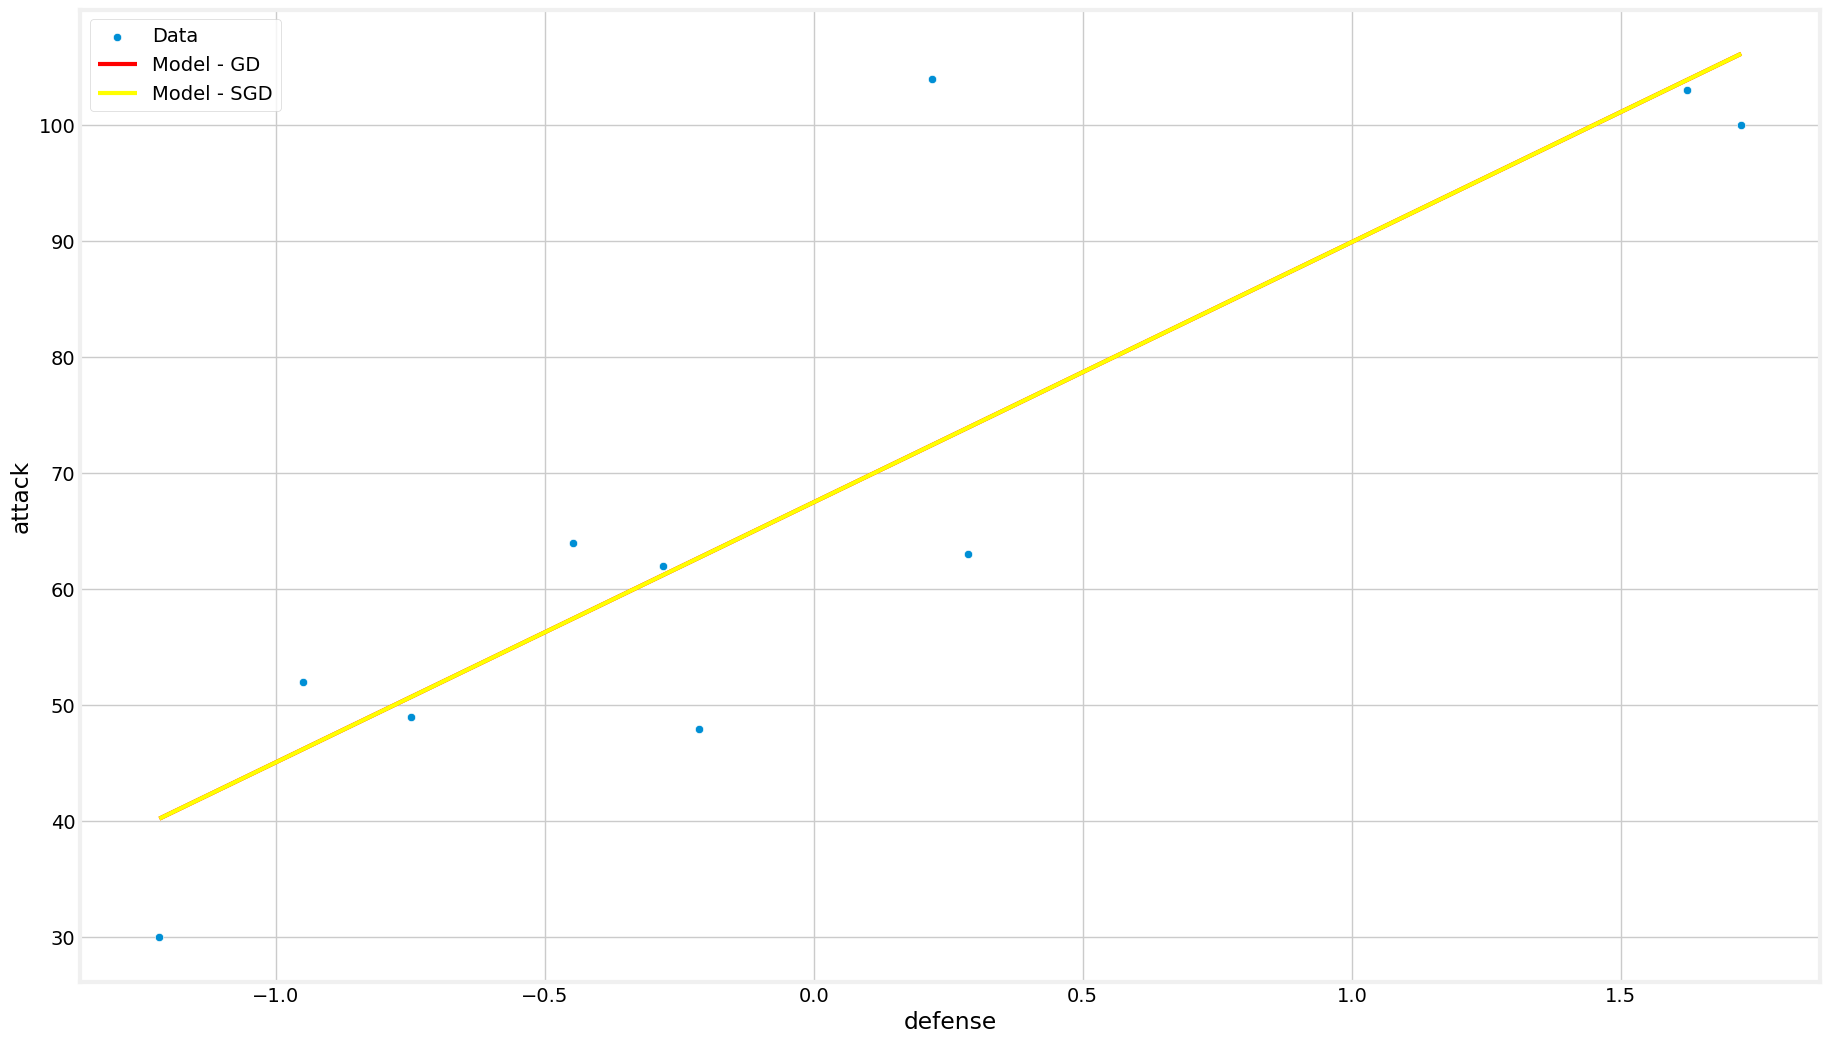

In [1933]:
ax = sns.scatterplot(x=x_scaled,y=y, label="Data")
ax.set(xlabel='defense', ylabel='attack')
sns.lineplot(x=x_scaled, y=preds.detach(), ax=ax, label='Model - GD', color='red')
sns.lineplot(x=x_scaled, y=preds.detach(), ax=ax, label='Model - SGD', color='yellow')

<h2><font color='#3498db'>Linear Regression Model using PyTorch built-ins and optimizers</font></h2>

In [1934]:
import torch.nn as nn

#### Model
Instead of initializing the weights & biases manually, we can define the model using `nn.Linear`.

In [1935]:
# Define model
model = nn.Linear(1, 1)
print(model.weight)
print(model.bias)

Parameter containing:
tensor([[0.6843]], requires_grad=True)
Parameter containing:
tensor([0.3476], requires_grad=True)



















#### Optimizer

Instead of manually manipulating the weights & biases using gradients, we can use the optimizer `optim.SGD`. Since we are going to use the whole training data to optimise the model paramters, the `optim.SGD` behaves like our implementation of the gradient descent above. However, given the quantity of the data available and the size of models nowadays it is impossible to use the whole data for a single parameter update.

In [1936]:
# model.weights = torch.tensor([[0.5]], requires_grad=True)#torch.randn(1, x_scaled.numel(), requires_grad=True)
# model.bias =  torch.nn.Parameter(torch.FloatTensor([10.0]), requires_grad=True)#torch.randn(1, requires_grad=True)
# Define optimizer
learning_rates = [0.001, 0.01, 0.2, 0.5, 0.8, 1.0]

#opt = torch.optim.SGD(model.parameters(), lr=0.8)

#### Loss Function
We also do not need to define the loss function manually. Instead we can use the built-in loss function mse_loss.

In [1937]:
# Import nn.functional
import torch.nn.functional as F

# Define loss function
loss_fn = F.mse_loss
y_m = y.unsqueeze(1)
loss = loss_fn(model(x_scaled_m), y_m)
print(loss)

tensor(5090.2959, grad_fn=<MseLossBackward0>)


#### Fit the model

We are ready to train the model now. We define a function called `fit` that trains the model for a given number of epochs.


In [1938]:
def fit(x, y, num_epochs, model, loss_fn, opt, report_progress=10):
    for epoch in range(num_epochs):
        # Generate predictions
        pred = model(x)
        loss = loss_fn(pred, y)
        # Perform gradient descent
        loss.backward()
        opt.step()
        opt.zero_grad()
        if epoch % report_progress == 0:
            if epoch == 0 or epoch == 990:
                print(f'Epoch {epoch}. w = {model.weight}. b = {model.bias}.')

# Train the model for 1000 epochs
for lr in learning_rates:
    print(f"\nTraining with learning rate = {lr}")

    # Reinitialize the model before each experiment
    model = nn.Linear(1, 1)
    
    opt = torch.optim.SGD(model.parameters(), lr=lr)

    fit(x_scaled_m, y_m.float(), 1000, model, loss_fn, opt)


Training with learning rate = 0.001
Epoch 0. w = Parameter containing:
tensor([[0.2969]], requires_grad=True). b = Parameter containing:
tensor([-0.0739], requires_grad=True).
Epoch 990. w = Parameter containing:
tensor([[18.7062]], requires_grad=True). b = Parameter containing:
tensor([58.1886], requires_grad=True).

Training with learning rate = 0.01
Epoch 0. w = Parameter containing:
tensor([[0.4155]], requires_grad=True). b = Parameter containing:
tensor([1.0272], requires_grad=True).
Epoch 990. w = Parameter containing:
tensor([[22.4243]], requires_grad=True). b = Parameter containing:
tensor([67.4998], requires_grad=True).

Training with learning rate = 0.2
Epoch 0. w = Parameter containing:
tensor([[8.4538]], requires_grad=True). b = Parameter containing:
tensor([27.2021], requires_grad=True).
Epoch 990. w = Parameter containing:
tensor([[22.4243]], requires_grad=True). b = Parameter containing:
tensor([67.5000], requires_grad=True).

Training with learning rate = 0.5
Epoch 0. 

#### <span style="color:green">Exercise 2</span>  
<span style="color:green">Experiment different learning rates in the PyTorch optimiser.</span>

- ***Answer:***
    1. **Small Learning Rates (0.001, 0.01)**
        - **Observation:** The weight (`w`) and bias (`b`) increase slowly over epochs but remain lower than those obtained with larger learning rates.
        - **Implication:** A small learning rate results in slow convergence. While this prevents overshooting, it may take an excessive number of epochs to reach optimal parameter values.
    2. **Moderate Learning Rates (0.2, 0.5)**
        - **Observation:** The model converges to approximately `w ≈ 22.42` and `b ≈ 67.50`, indicating stable learning.
        - **Implication:** This range provides a balance between speed and stability, making it ideal for efficient training.
    3. **High Learning Rates (0.8, 1.0)**
        - **Observation:**
            - The initial weight and bias values start much larger compared to lower learning rates.
            - For `lr = 0.8`, the model still converges to reasonable values (`w ≈ 22.42, b ≈ 67.50`).
            - For `lr = 1.0`, the weight (`w`) converges correctly, but the bias (`b`) remains at `134.91`, indicating instability.
        - **Implication:**
            - Large learning rates lead to big parameter updates, which may cause the model to overshoot optimal values.
            - In extreme cases, some parameters may diverge or fail to converge properly (as seen with `b` at `lr = 1.0`).

    - **Key Takeaways**
        1. **Too Small (`0.001`)** → Convergence is too slow, making training inefficient.
        2. **Optimal Range (`0.2 - 0.5`)** → Fast and stable learning, recommended for training.
        3. **Too Large (`0.8 - 1.0`)** → Can cause overshooting or instability, leading to poor parameter updates.

    - **Recommendations**
        - For **fast and stable training**, use `lr = 0.2` or `lr = 0.5`.
        - If training is **too slow**, increase the learning rate from `0.001` to `0.01` or higher.
        - If parameters **diverge or overshoot**, reduce the learning rate (e.g., avoid `1.0`).

#### <span style="color:green">Exercise 3</span>  
<span style="color:green">Study the impact of the momentum in optimiser.</span>

In [1939]:
# Define optimizer with momentum
momentum_values = [0.0, 0.5, 0.9]  # Different values for momentum

for momentum in momentum_values:
    print(f"\nTraining with learning rate = 0.2, momentum = {momentum}")
    
    # Reset model weights and bias before each training session
    model = nn.Linear(1, 1)
    
    # Use SGD optimizer with momentum
    opt = torch.optim.SGD(model.parameters(), lr=0.2, momentum=momentum)
    
    # Train the model
    fit(x_scaled_m, y_m.float(), 1000, model, loss_fn, opt)


Training with learning rate = 0.2, momentum = 0.0
Epoch 0. w = Parameter containing:
tensor([[8.5374]], requires_grad=True). b = Parameter containing:
tensor([26.8817], requires_grad=True).
Epoch 990. w = Parameter containing:
tensor([[22.4243]], requires_grad=True). b = Parameter containing:
tensor([67.5000], requires_grad=True).

Training with learning rate = 0.2, momentum = 0.5
Epoch 0. w = Parameter containing:
tensor([[7.9809]], requires_grad=True). b = Parameter containing:
tensor([26.6026], requires_grad=True).
Epoch 990. w = Parameter containing:
tensor([[22.4243]], requires_grad=True). b = Parameter containing:
tensor([67.5000], requires_grad=True).

Training with learning rate = 0.2, momentum = 0.9
Epoch 0. w = Parameter containing:
tensor([[8.2556]], requires_grad=True). b = Parameter containing:
tensor([27.4854], requires_grad=True).
Epoch 990. w = Parameter containing:
tensor([[22.4243]], requires_grad=True). b = Parameter containing:
tensor([67.5000], requires_grad=True)

- ***Answer:***
    1. **All momentum values converge to the same final weights and bias**
        - Regardless of the momentum value, the final weights (w ≈ 22.4243) and bias (b ≈ 67.5000) are identical after 990 epochs.
        - This suggests that momentum does not change the ultimate solution but affects the convergence dynamics.
    2. **Momentum affects the initial steps of training**
        - At Epoch 0, the initialized values for w and b are different for each momentum setting.
        - With momentum = 0.5, the initial values of w and b are slightly lower than those with momentum = 0.0.
        - With momentum = 0.9, the initial values are slightly different, but not drastically so.
    3. **Momentum accelerates convergence in the presence of high curvature**
        - In general, higher momentum values (like 0.9) help smooth out oscillations and speed up convergence, especially in cases with high curvature or noisy gradients.
        - However, since your dataset is simple and well-behaved, momentum does not show a drastic improvement.
    - **Key Takeaways:**
        - Momentum helps stabilize updates: It accumulates past gradients, reducing oscillations in noisy settings.
        - Higher momentum values can speed up convergence: They prevent the model from getting stuck in local minima and help reach the optimal weights faster.
        - In this case, momentum does not significantly change the final outcome: Since the problem is relatively simple, all settings converge to the same solution.

#### <span style="color:green">Exercise 4</span>  
<span style="color:green">Use the following dataset about the California Housing to create a linear model to predict the House Price based on the income.</span>

In [1940]:
from sklearn.datasets import fetch_california_housing
housing_data = fetch_california_housing()
features = pd.DataFrame(housing_data.data, columns=housing_data.feature_names)
targets = pd.DataFrame(housing_data.target, columns=['Target'])
df = features.join(targets)
X = df.MedInc
y = df.Target

[Text(0.5, 0, 'income'), Text(0, 0.5, 'houseprice')]

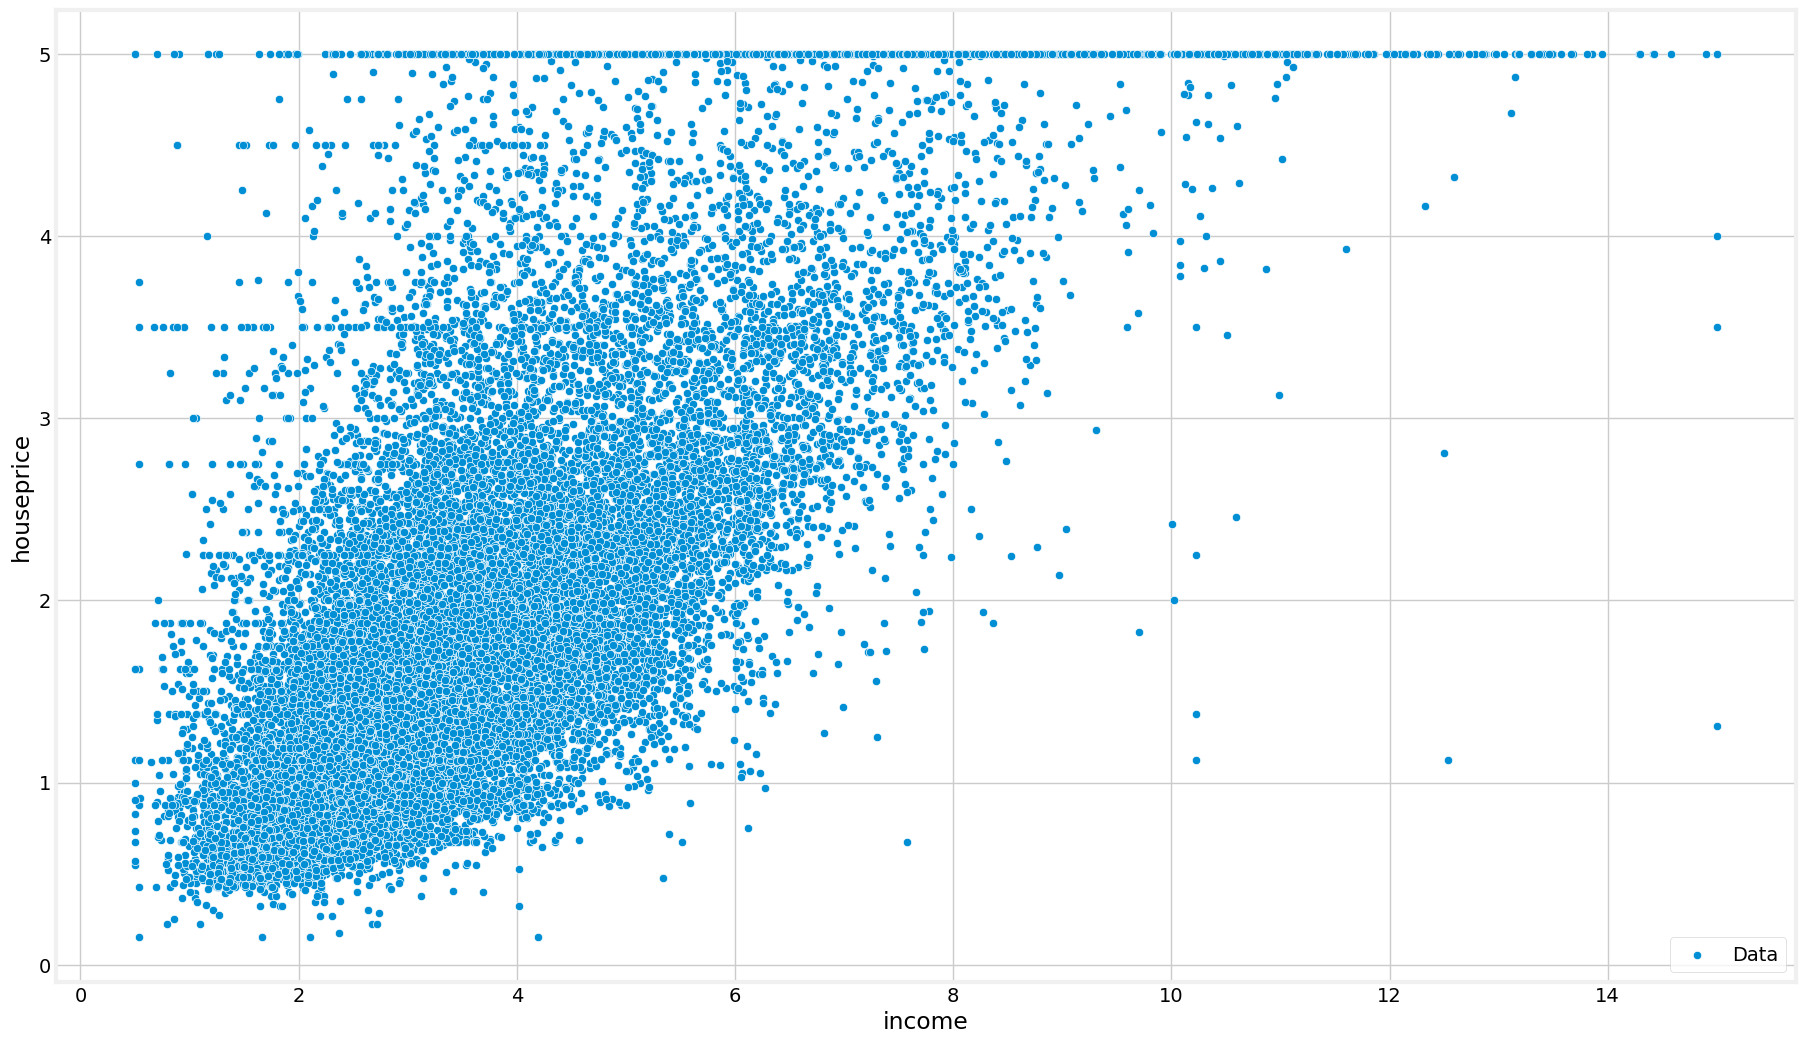

In [1941]:
ax = sns.scatterplot(x=X, y=y, label="Data")
ax.set(xlabel='income', ylabel='houseprice')

Epoch 0. Loss: 9.44405746459961
Epoch 10. Loss: 0.701450765132904
Epoch 20. Loss: 0.7011311650276184
Epoch 30. Loss: 0.7011311650276184
Epoch 40. Loss: 0.7011311650276184
Epoch 50. Loss: 0.7011311650276184
Epoch 60. Loss: 0.7011311650276184
Epoch 70. Loss: 0.7011311650276184
Epoch 80. Loss: 0.7011311650276184
Epoch 90. Loss: 0.7011311650276184
Epoch 100. Loss: 0.7011311650276184
Epoch 110. Loss: 0.7011311650276184
Epoch 120. Loss: 0.7011311650276184
Epoch 130. Loss: 0.7011311650276184
Epoch 140. Loss: 0.7011311650276184
Epoch 150. Loss: 0.7011311650276184
Epoch 160. Loss: 0.7011311650276184
Epoch 170. Loss: 0.7011311650276184
Epoch 180. Loss: 0.7011311650276184
Epoch 190. Loss: 0.7011311650276184
Epoch 200. Loss: 0.7011311650276184
Epoch 210. Loss: 0.7011311650276184
Epoch 220. Loss: 0.7011311650276184
Epoch 230. Loss: 0.7011311650276184
Epoch 240. Loss: 0.7011311650276184
Epoch 250. Loss: 0.7011311650276184
Epoch 260. Loss: 0.7011311650276184
Epoch 270. Loss: 0.7011311650276184
Epoch 

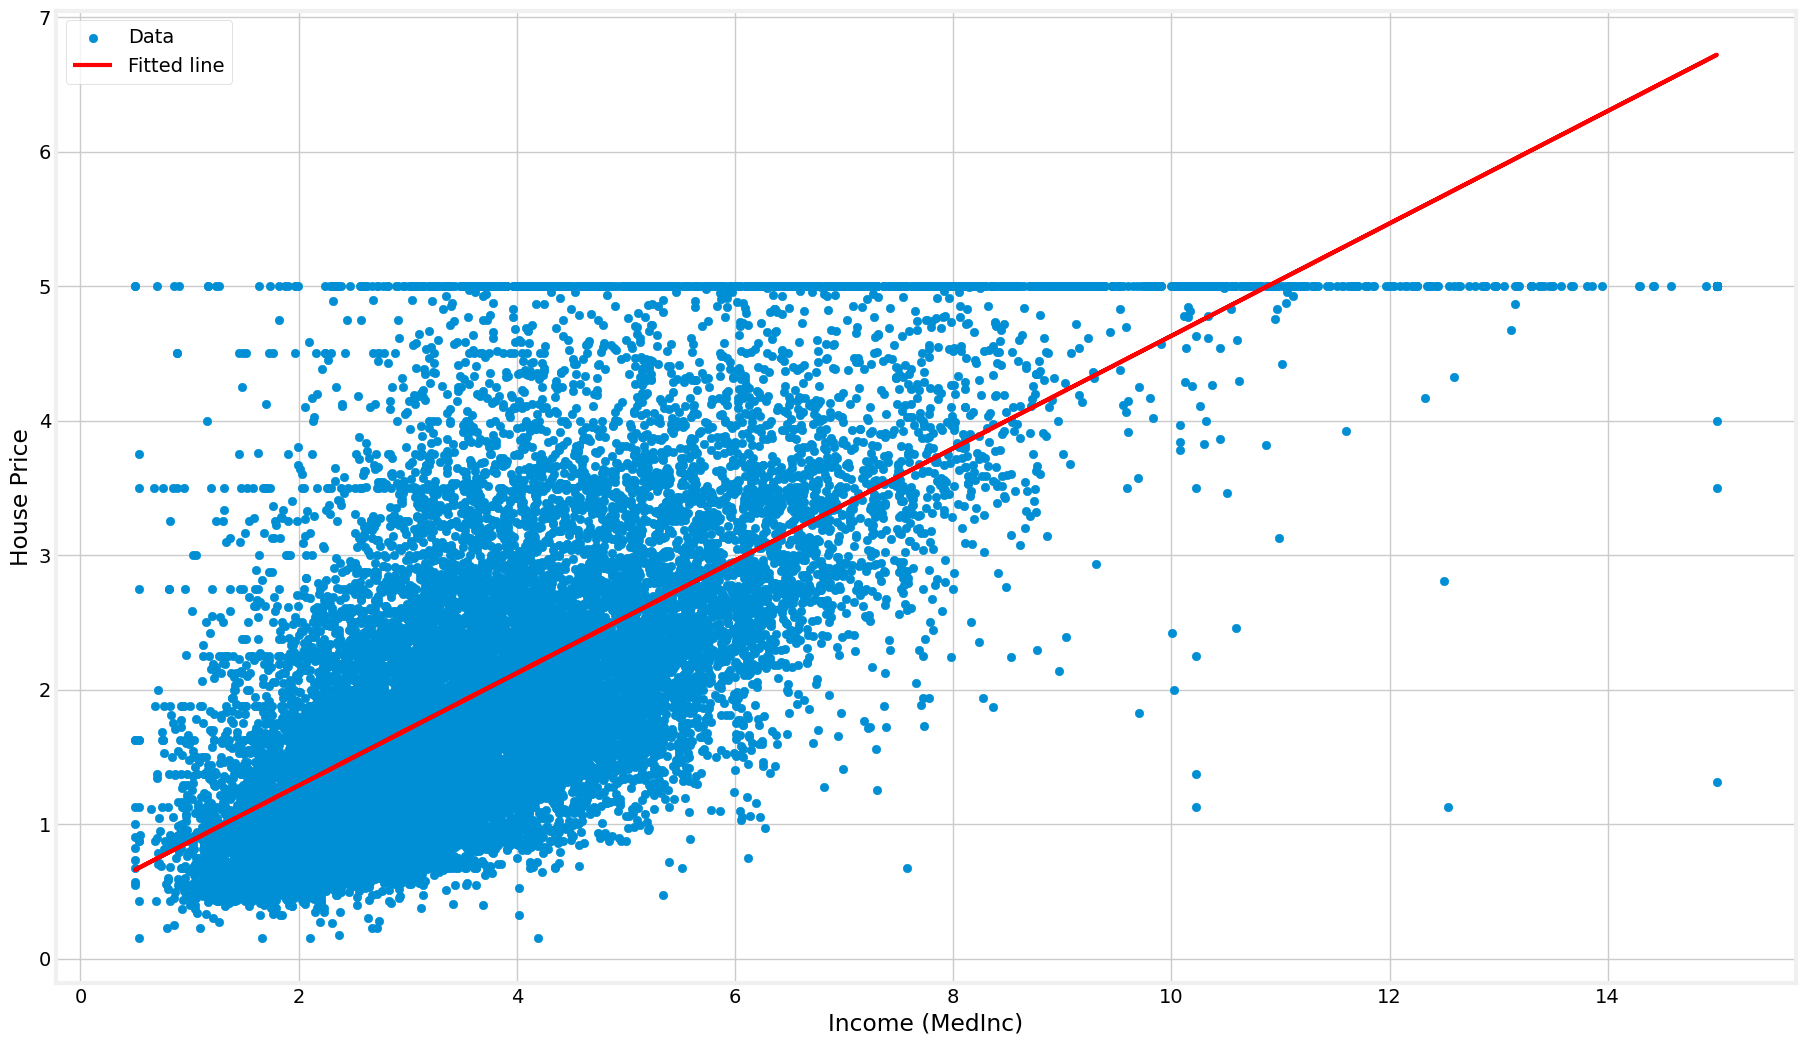

In [1942]:
# Extract the 'MedInc' feature and target values
X = df['MedInc'].values.reshape(-1, 1)
y = df['Target'].values

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to tensors
x_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

# Define the model
model = nn.Linear(1, 1)

# Define the optimizer and loss function
optimizer = torch.optim.SGD(model.parameters(), lr=0.2)
loss_fn = F.mse_loss

# Training function
def fit(x, y, num_epochs, model, loss_fn, opt, report_progress=10):
    for epoch in range(num_epochs):
        # Generate predictions
        pred = model(x)
        loss = loss_fn(pred, y)
        
        # Perform gradient descent
        loss.backward()
        opt.step()
        opt.zero_grad()

        if epoch % report_progress == 0:
            print(f'Epoch {epoch}. Loss: {loss.item()}')

# Train the model for 1000 epochs
fit(x_tensor, y_tensor, 1000, model, loss_fn, optimizer)

# Predictions
predictions = model(x_tensor).detach().numpy()

# Plot the data
plt.figure()
plt.scatter(X, y, label="Data",)
plt.plot(X, predictions, label="Fitted line", color="red")
plt.xlabel('Income (MedInc)')
plt.ylabel('House Price')
plt.legend()
plt.show()